# A_S2.1 — Observed Metric Distribution Visualization

Visualizes the deterministic metrics computed in A_S2 across the four relationship categories.

| Section | Question |
|---------|----------|
| 1. Category overview | How do metric values distribute across the 4 categories? |
| 2. Core metrics by SNR | How does signal strength affect metric values? |
| 3. Function family profiles | Which functions are hard/easy to detect? |
| 4. Metric correlation matrix | Which metrics carry redundant vs. complementary information? |
| 5. Variance-only focus | Can any metric pick up spread-only dependence? |
| 6. Spread pattern effect | How does heteroscedasticity shape metric behavior? |
| 7. X-distribution influence | Does sampling density bias metric values? |

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
%matplotlib inline

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')
VIZ_DIR = Path('output/S2/viz')
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Load case metadata
cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_main['source'] = 'main'
cases_null['source'] = 'null_expanded'
offset = cases_main['case_id'].max()
cases_null['case_id'] = cases_null['case_id'] + offset
cases_df = pd.concat([cases_main, cases_null], ignore_index=True)

# Assign categories
is_null = cases_df['family_id'] == 'Null'
is_const = cases_df['spread_pattern'] == 'constant'
cases_df['category'] = 'mean+variance'
cases_df.loc[is_null & is_const, 'category'] = 'true_null'
cases_df.loc[~is_null & is_const, 'category'] = 'mean_only'
cases_df.loc[is_null & ~is_const, 'category'] = 'variance_only'

# Load metrics
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')
df = cases_df.merge(metrics, on='case_id', suffixes=('', '_m'))

print(f'Loaded {len(df):,} cases with {len(metrics.columns)} metric columns')
print(df['category'].value_counts())

Loaded 121,056 cases with 78 metric columns
category
mean+variance    85536
mean_only        28512
true_null         4032
variance_only     2976
Name: count, dtype: int64


In [2]:
CAT_ORDER = ['true_null', 'variance_only', 'mean_only', 'mean+variance']
CAT_COLORS = {'true_null': '#999999', 'variance_only': '#f59e0b',
              'mean_only': '#3b82f6', 'mean+variance': '#10b981'}
CAT_LABELS = {'true_null': 'True Null', 'variance_only': 'Variance-only',
              'mean_only': 'Mean-only', 'mean+variance': 'Mean+Variance'}

CORE_METRICS = ['pearson_r', 'spearman_rho', 'distance_correlation', 'ew_bin_eta_squared']
CORE_LABELS = ['|Pearson r|', '|Spearman ρ|', 'Distance Correlation', 'η² (equal-width)']

# Use absolute values for correlation metrics
for col in ['pearson_r', 'spearman_rho']:
    if col in df.columns:
        df[col] = df[col].abs()

# Map eta_squared column name if needed
if 'equal_width_bin_eta_squared' in df.columns and 'ew_bin_eta_squared' not in df.columns:
    df['ew_bin_eta_squared'] = df['equal_width_bin_eta_squared']
if 'equal_count_bin_eta_squared' in df.columns and 'ec_bin_eta_squared' not in df.columns:
    df['ec_bin_eta_squared'] = df['equal_count_bin_eta_squared']

## 1. Category Overview — Violin Plots of Core Metrics

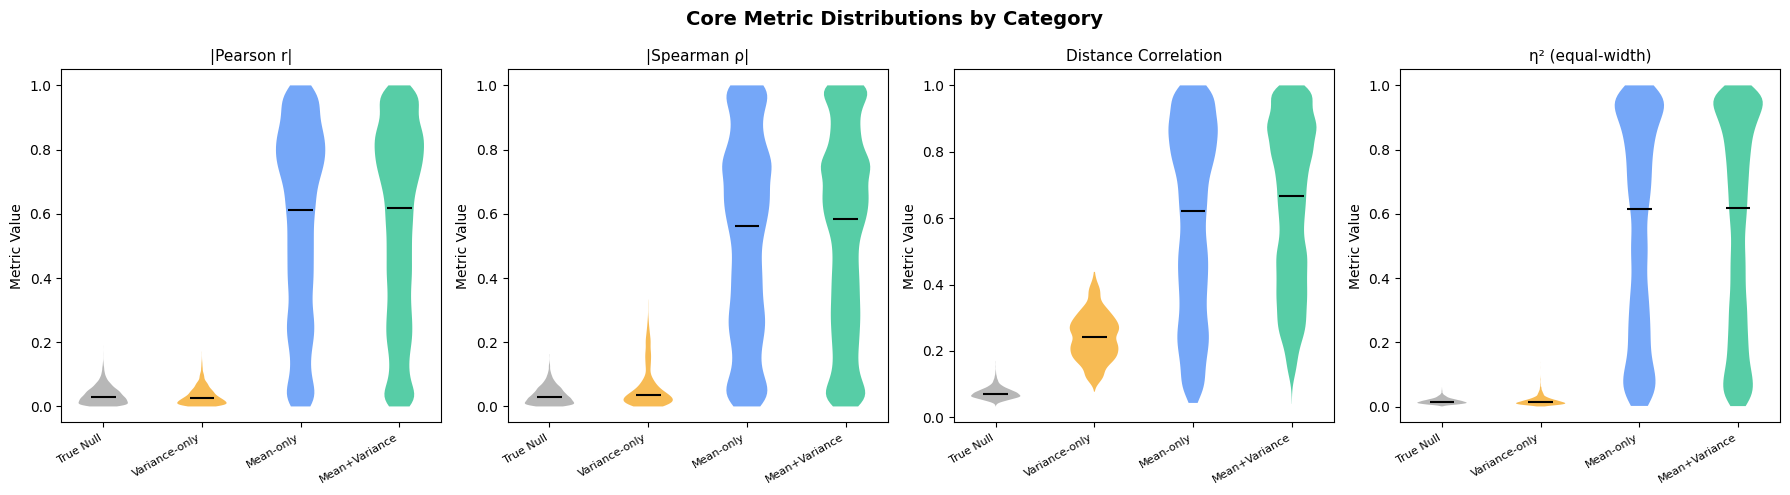

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric, label in zip(axes, CORE_METRICS, CORE_LABELS):
    if metric not in df.columns:
        ax.set_title(f'{label}\n(not available)', fontsize=10)
        continue
    data = [df.loc[df['category'] == cat, metric].dropna().values for cat in CAT_ORDER]
    parts = ax.violinplot(data, positions=range(len(CAT_ORDER)), showmedians=True, showextrema=False)
    for pc, cat in zip(parts['bodies'], CAT_ORDER):
        pc.set_facecolor(CAT_COLORS[cat])
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    ax.set_xticks(range(len(CAT_ORDER)))
    ax.set_xticklabels([CAT_LABELS[c] for c in CAT_ORDER], rotation=30, ha='right', fontsize=8)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Metric Value')

plt.suptitle('Core Metric Distributions by Category', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig1_category_violins.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Core Metrics vs SNR

Mean-only cases (constant spread): how metric values rise with signal strength.

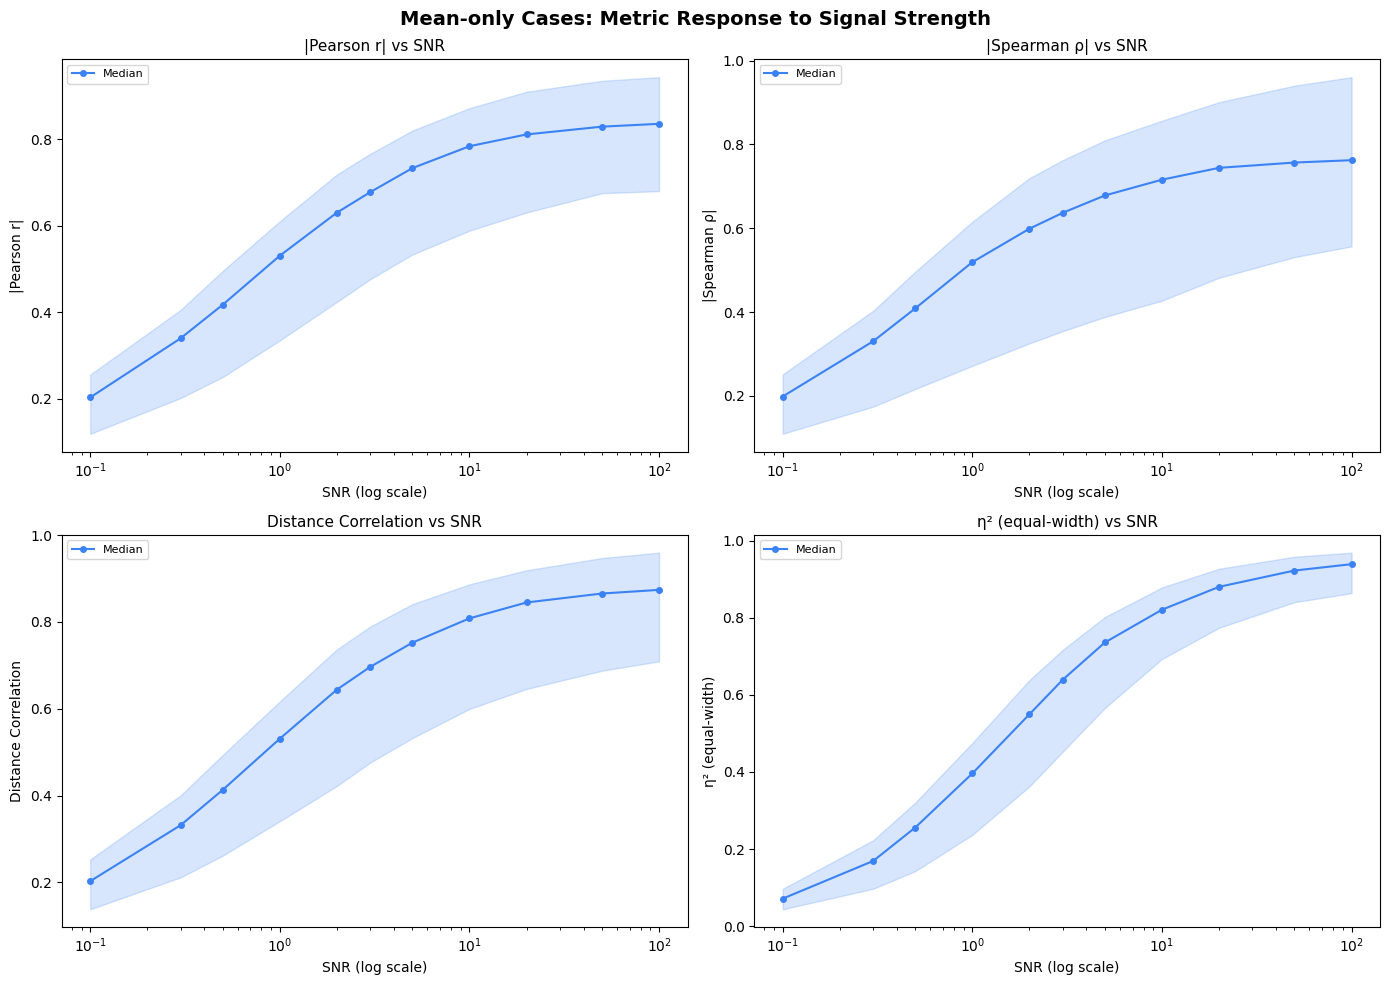

In [4]:
mean_only = df[df['category'] == 'mean_only'].copy()
mean_only['snr_num'] = pd.to_numeric(mean_only['snr'], errors='coerce')
mean_only = mean_only[mean_only['snr_num'].notna() & np.isfinite(mean_only['snr_num'])]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in mean_only.columns:
        ax.set_title(f'{label} (not available)')
        continue
    grouped = mean_only.groupby('snr_num')[metric].agg(['median', 'mean',
        lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    grouped.columns = ['snr', 'median', 'mean', 'q25', 'q75']
    ax.fill_between(grouped['snr'], grouped['q25'], grouped['q75'],
                    alpha=0.2, color='#3b82f6')
    ax.plot(grouped['snr'], grouped['median'], 'o-', color='#3b82f6',
            markersize=4, label='Median')
    ax.set_xscale('log')
    ax.set_xlabel('SNR (log scale)')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs SNR', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Mean-only Cases: Metric Response to Signal Strength',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig2_snr_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Function Family Profiles

Heatmap: mean metric value per family (mean-only, SNR=2.0, even distribution).

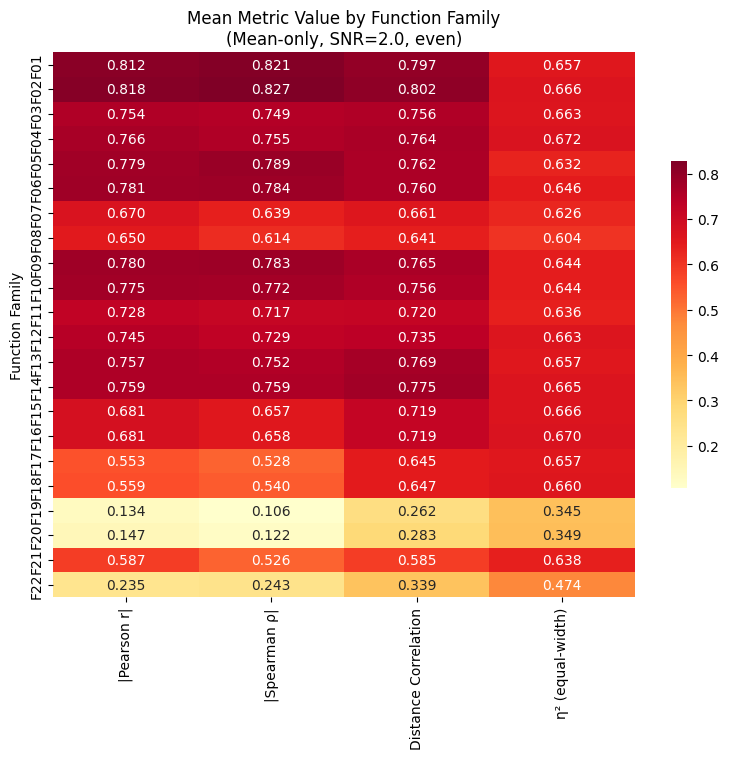

In [5]:
subset = df[(df['category'] == 'mean_only') &
            (df['snr'] == 2.0) &
            (df['x_distribution'] == 'even')].copy()

available_metrics = [m for m in CORE_METRICS if m in subset.columns]
available_labels = [l for m, l in zip(CORE_METRICS, CORE_LABELS) if m in subset.columns]

if len(available_metrics) > 0 and len(subset) > 0:
    family_means = subset.groupby('family_id')[available_metrics].mean()
    family_means = family_means.loc[family_means.index != 'Null']

    fig, ax = plt.subplots(figsize=(8, max(6, len(family_means) * 0.35)))
    sns.heatmap(family_means, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=available_labels, ax=ax, cbar_kws={'shrink': 0.6})
    ax.set_title('Mean Metric Value by Function Family\n(Mean-only, SNR=2.0, even)', fontsize=12)
    ax.set_ylabel('Function Family')
    plt.tight_layout()
    fig.savefig(VIZ_DIR / 'fig3_family_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough data for family heatmap')

## 4. Metric Correlation Matrix

Pairwise Pearson correlation of all numeric metrics across all cases.

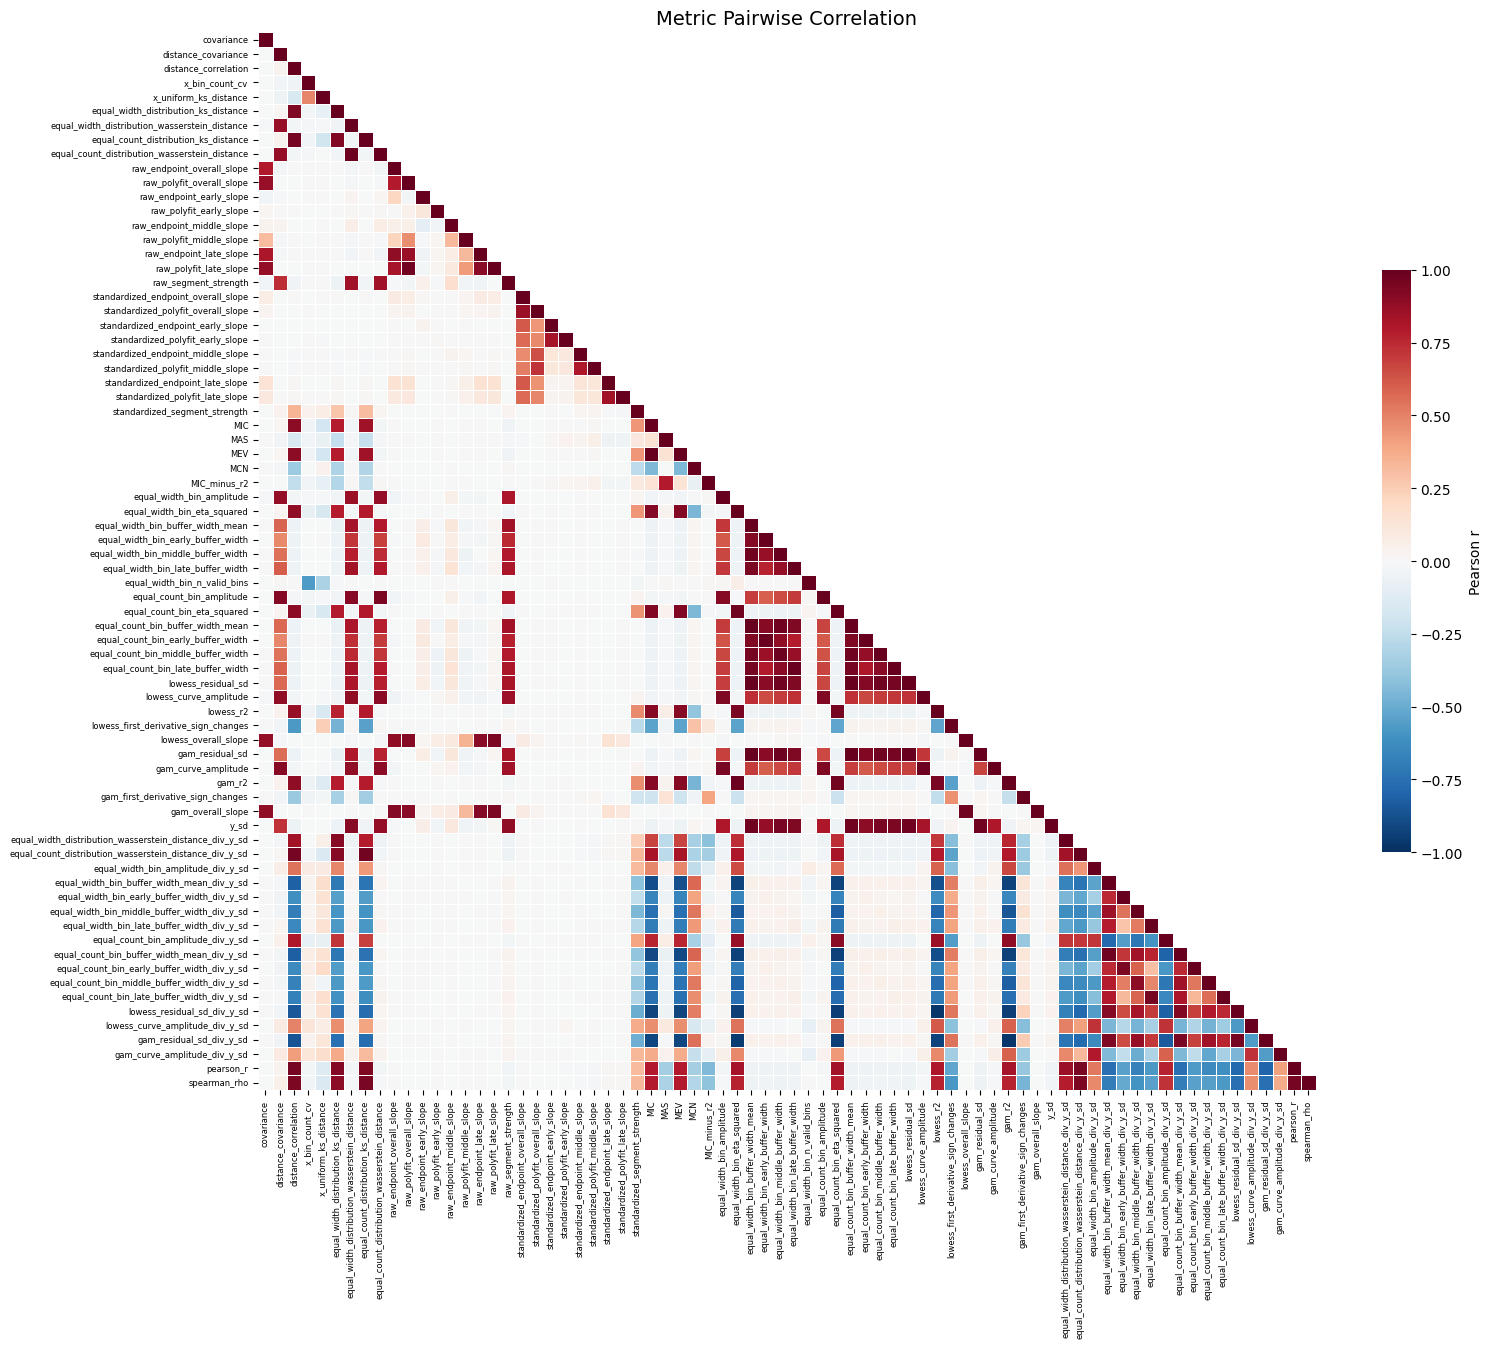

74 metrics in correlation matrix


In [6]:
metric_cols = [c for c in metrics.columns if c not in ('case_id', 'source', 'n_valid')
               and df[c].dtype in ('float64', 'float32', 'int64')]

# Filter to columns with reasonable variance
metric_cols = [c for c in metric_cols if df[c].std() > 1e-10]

corr = df[metric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={'shrink': 0.5, 'label': 'Pearson r'})
ax.set_title('Metric Pairwise Correlation', fontsize=14)
ax.tick_params(labelsize=6)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig4_metric_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{len(metric_cols)} metrics in correlation matrix')

## 5. Variance-Only Focus

Which metrics can distinguish variance-only cases from true null?
Compare distributions of each metric for true_null vs variance_only.

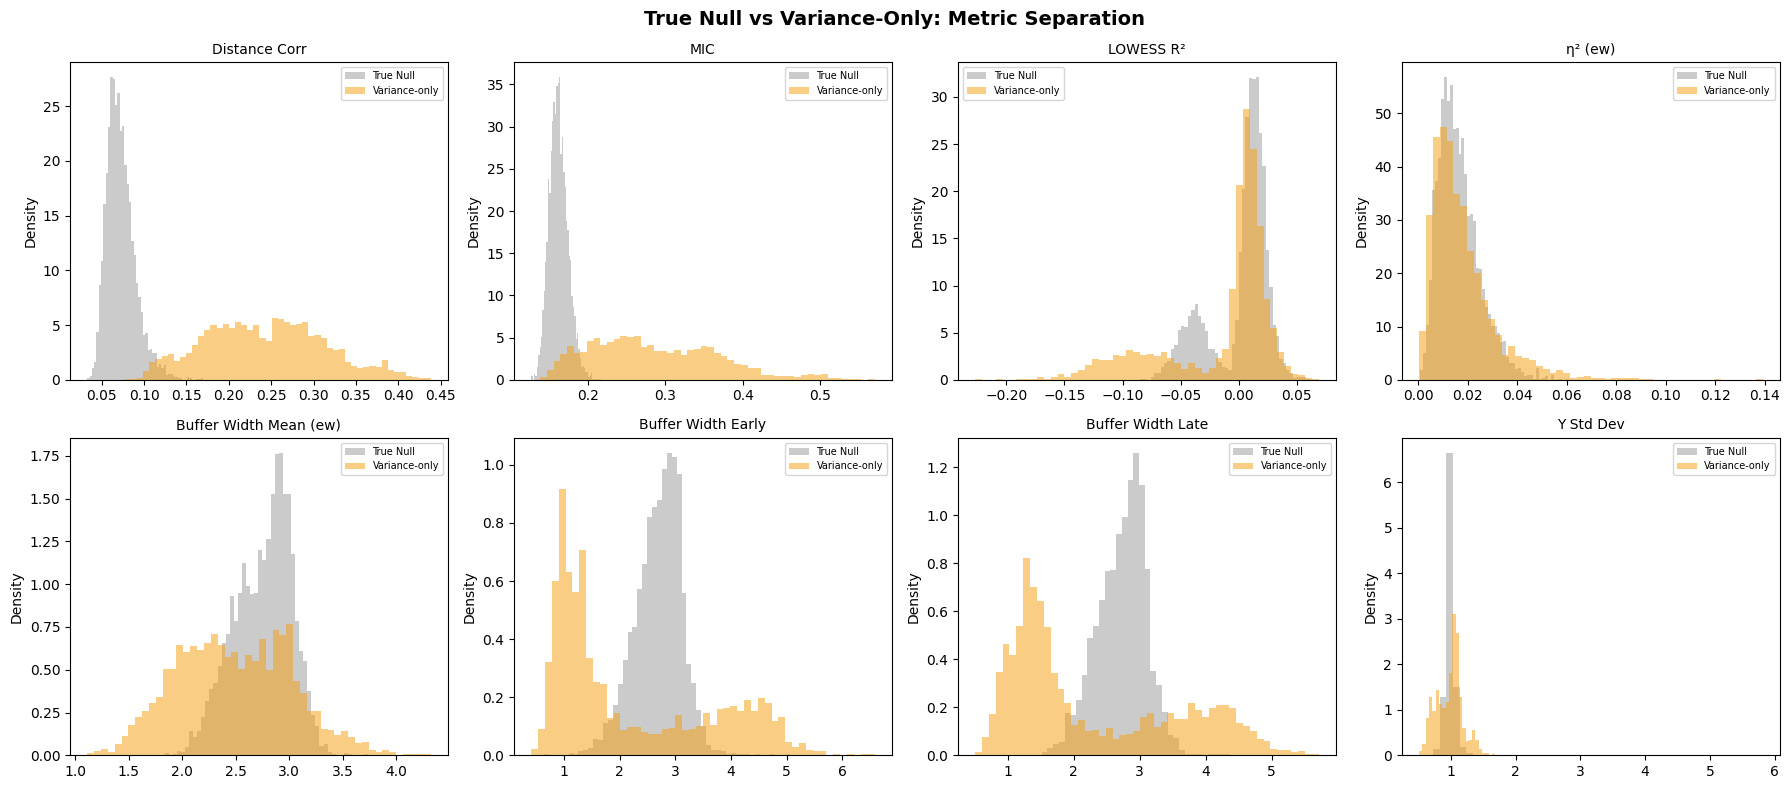

In [7]:
tn = df[df['category'] == 'true_null']
vo = df[df['category'] == 'variance_only']

# Candidate metrics sensitive to spread changes
spread_metrics = [
    ('distance_correlation', 'Distance Corr'),
    ('MIC', 'MIC'),
    ('lowess_r2', 'LOWESS R²'),
    ('ew_bin_eta_squared', 'η² (ew)'),
]
# Add buffer width metrics if available
for col_name, label in [
    ('equal_width_bin_buffer_width_mean', 'Buffer Width Mean (ew)'),
    ('equal_width_bin_early_buffer_width', 'Buffer Width Early'),
    ('equal_width_bin_late_buffer_width', 'Buffer Width Late'),
    ('y_sd', 'Y Std Dev'),
]:
    if col_name in df.columns:
        spread_metrics.append((col_name, label))

available = [(m, l) for m, l in spread_metrics if m in df.columns]
n_plots = len(available)
ncols = min(4, n_plots)
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
if nrows == 1 and ncols == 1:
    axes = np.array([axes])
axes = axes.flat

for ax, (metric, label) in zip(axes, available):
    tn_vals = tn[metric].dropna()
    vo_vals = vo[metric].dropna()
    ax.hist(tn_vals, bins=50, alpha=0.5, color=CAT_COLORS['true_null'],
            density=True, label='True Null')
    ax.hist(vo_vals, bins=50, alpha=0.5, color=CAT_COLORS['variance_only'],
            density=True, label='Variance-only')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylabel('Density')

# Hide unused axes
for j in range(n_plots, nrows * ncols):
    fig.delaxes(list(fig.axes)[j])

plt.suptitle('True Null vs Variance-Only: Metric Separation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig5_variance_only_separation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Spread Pattern Effect

For a fixed function family (F01, SNR=2.0), how do metrics change across spread patterns?

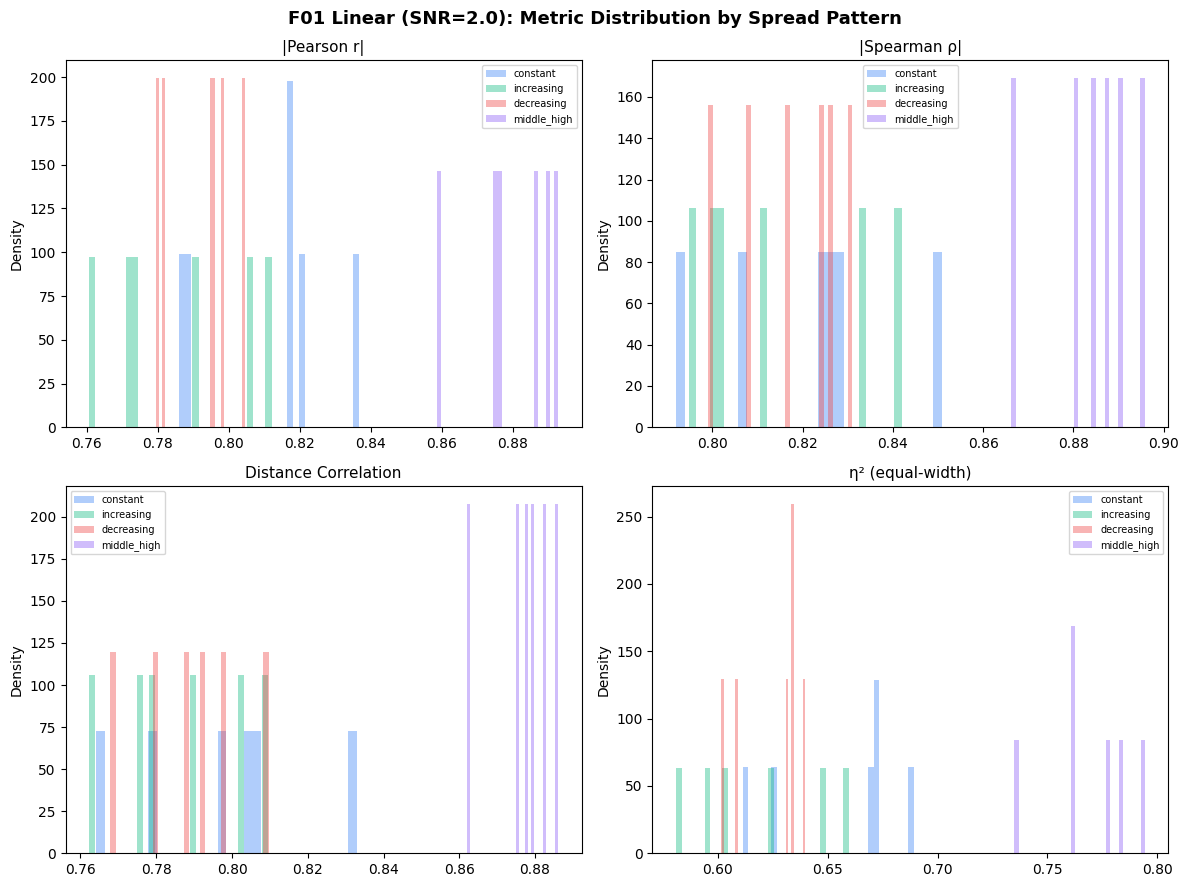

In [8]:
f01 = df[(df['family_id'] == 'F01') & (df['snr'] == 2.0) &
         (df['x_distribution'] == 'even') & (df['source_x'] == 'main')].copy() \
    if 'source_x' in df.columns else \
    df[(df['family_id'] == 'F01') & (df['snr'] == 2.0) &
       (df['x_distribution'] == 'even')].copy()

spread_order = ['constant', 'increasing', 'decreasing', 'middle_high']
spread_colors = {'constant': '#3b82f6', 'increasing': '#10b981',
                 'decreasing': '#ef4444', 'middle_high': '#8b5cf6'}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in f01.columns:
        ax.set_visible(False)
        continue
    for sp in spread_order:
        vals = f01.loc[f01['spread_pattern'] == sp, metric].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=30, alpha=0.4, color=spread_colors[sp],
                    density=True, label=sp)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=7)
    ax.set_ylabel('Density')

plt.suptitle('F01 Linear (SNR=2.0): Metric Distribution by Spread Pattern',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig6_spread_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. X-Distribution Influence

Does the sampling density of X bias metric values?
Boxplots of core metrics grouped by x_distribution (mean-only, SNR=2.0).

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_32403/2063261605.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=x_dist_short, patch_artist=True,
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_32403/2063261605.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=x_dist_short, patch_artist=True,
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_32403/2063261605.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=x_dist_short, patch_artist=True,
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipy

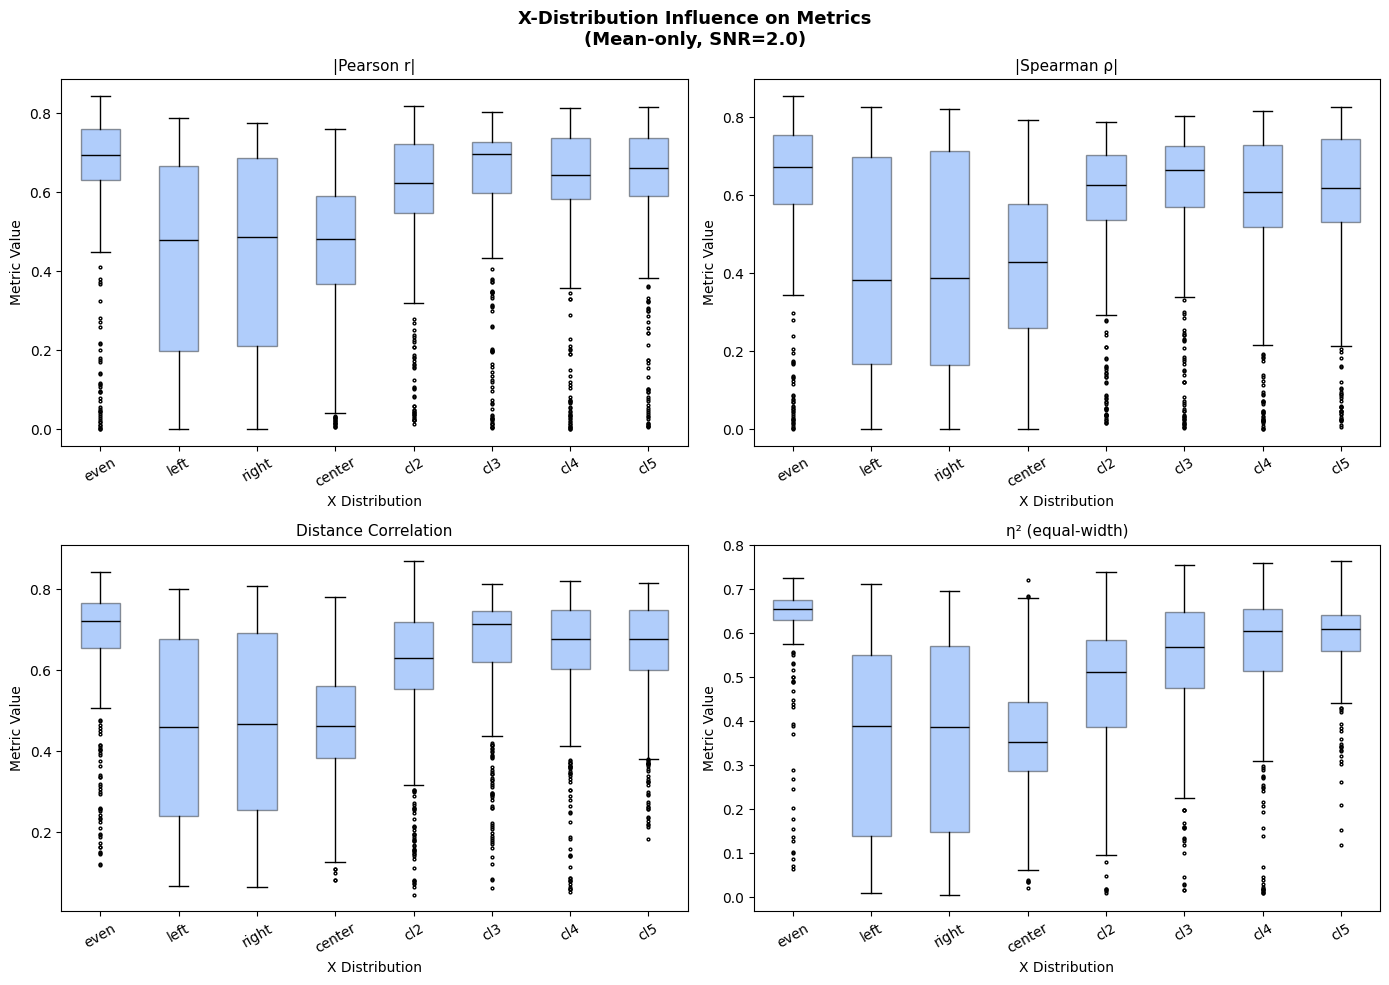

In [9]:
xdist_sub = df[(df['category'] == 'mean_only') & (df['snr'] == 2.0)].copy()

x_dist_order = ['even', 'left_dense', 'right_dense', 'center_dense',
                'clusters_2', 'clusters_3', 'clusters_4', 'clusters_5']
x_dist_short = ['even', 'left', 'right', 'center', 'cl2', 'cl3', 'cl4', 'cl5']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in xdist_sub.columns:
        ax.set_visible(False)
        continue
    data = [xdist_sub.loc[xdist_sub['x_distribution'] == xd, metric].dropna().values
            for xd in x_dist_order]
    bp = ax.boxplot(data, labels=x_dist_short, patch_artist=True,
                    medianprops={'color': 'black'}, flierprops={'markersize': 2})
    for patch in bp['boxes']:
        patch.set_facecolor('#3b82f6')
        patch.set_alpha(0.4)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('X Distribution')
    ax.set_ylabel('Metric Value')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('X-Distribution Influence on Metrics\n(Mean-only, SNR=2.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig7_xdist_influence.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics

In [10]:
available_core = [m for m in CORE_METRICS if m in df.columns]
summary = df.groupby('category')[available_core].agg(['median', 'mean', 'std']).round(4)
display(summary)

print()
print('=== Metric Statistics ===')
for m, l in zip(CORE_METRICS, CORE_LABELS):
    if m in df.columns:
        for cat in CAT_ORDER:
            vals = df.loc[df['category'] == cat, m]
            print(f'  {l:25s}  {CAT_LABELS[cat]:15s}  '
              f'median={vals.median():.4f}  mean={vals.mean():.4f}  std={vals.std():.4f}')

pearson_r                 spearman_rho                  \
                 median    mean     std       median    mean     std   
category                                                               
mean+variance    0.6171  0.5596  0.2979       0.5853  0.5364  0.3016   
mean_only        0.6109  0.5562  0.2971       0.5627  0.5236  0.3021   
true_null        0.0302  0.0354  0.0268       0.0293  0.0351  0.0268   
variance_only    0.0255  0.0328  0.0275       0.0354  0.0594  0.0633   

              distance_correlation                 ew_bin_eta_squared          \
                            median    mean     std             median    mean   
category                                                                        
mean+variance               0.6661  0.6328  0.2456             0.6187  0.5581   
mean_only                   0.6225  0.5866  0.2802             0.6160  0.5529   
true_null                   0.0702  0.0728  0.0171             0.0151  0.0165   
variance_only               0.2421  0.2430  0.0702             0.0144  0.0177   

                       
                  std  
category               
mean+variance  0.3293  
mean_only      0.3296  
true_null      0.0084  
variance_only  0.0130


=== Metric Statistics ===
  |Pearson r|                True Null        median=0.0302  mean=0.0354  std=0.0268
  |Pearson r|                Variance-only    median=0.0255  mean=0.0328  std=0.0275
  |Pearson r|                Mean-only        median=0.6109  mean=0.5562  std=0.2971
  |Pearson r|                Mean+Variance    median=0.6171  mean=0.5596  std=0.2979
  |Spearman ρ|               True Null        median=0.0293  mean=0.0351  std=0.0268
  |Spearman ρ|               Variance-only    median=0.0354  mean=0.0594  std=0.0633
  |Spearman ρ|               Mean-only        median=0.5627  mean=0.5236  std=0.3021
  |Spearman ρ|               Mean+Variance    median=0.5853  mean=0.5364  std=0.3016
  Distance Correlation       True Null        median=0.0702  mean=0.0728  std=0.0171
  Distance Correlation       Variance-only    median=0.2421  mean=0.2430  std=0.0702
  Distance Correlation       Mean-only        median=0.6225  mean=0.5866  std=0.2802
  Distance Correlation       Mean+Vari